In [16]:
# Step 1: Import Libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style('whitegrid')

In [17]:
# Step 2: Load Dataset
df = pd.read_csv(
    'IMDB_Dataset.csv',
    encoding_errors='ignore',
    on_bad_lines='skip',
    engine='python'
)

df.columns = ['review', 'sentiment']
df = df.dropna()
df = df[df['sentiment'].isin(['positive', 'negative'])].copy()

print('Dataset shape:', df.shape)
print(df.head())
print('\nSentiment count:')
print(df['sentiment'].value_counts())

Dataset shape: (49612, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Sentiment count:
sentiment
negative    24813
positive    24799
Name: count, dtype: int64


In [18]:
# Step 3: Clean Text and Convert Labels
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1}).astype('int32')

print(df[['review', 'sentiment', 'label']].head())

                                              review sentiment  label
0  one of the other reviewers has mentioned that ...  positive      1
1  a wonderful little production the filming tech...  positive      1
2  i thought this was a wonderful way to spend ti...  positive      1
3  basically there s a family where a little boy ...  negative      0
4  petter mattei s love in the time of money is a...  positive      1


In [19]:
# Step 4: Train-Test Split Before Vectorization
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['review'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print('Training reviews:', X_train_text.shape[0])
print('Testing reviews:', X_test_text.shape[0])

Training reviews: 39689
Testing reviews: 9923


In [20]:
# Step 5: TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')

X_train = vectorizer.fit_transform(X_train_text).astype('float32').toarray()
X_test = vectorizer.transform(X_test_text).astype('float32').toarray()

y_train = y_train.to_numpy().astype('float32')
y_test = y_test.to_numpy().astype('float32')

print('Train matrix:', X_train.shape)
print('Test matrix:', X_test.shape)

Train matrix: (39689, 3000)
Test matrix: (9923, 3000)


In [21]:
# Step 6: Build Binary Classification DNN
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       384,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,449 (1.50 MB)

 Trainable params: 392,449 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Step 7: Train Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

Test Accuracy: 0.8787664771080017
Test Loss: 0.28812023997306824
Precision: 0.8673968316057109
Recall: 0.8941532258064516
F1 Score: 0.8805718256725901
ROC AUC: 0.9496047160276369

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.86      0.88      4963
    positive       0.87      0.89      0.88      4960

    accuracy                           0.88      9923
   macro avg       0.88      0.88      0.88      9923
weighted avg       0.88      0.88      0.88      9923



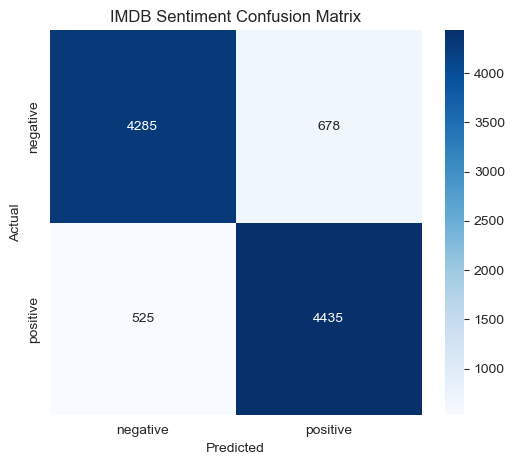

In [23]:
# Step 8: Final Evaluation
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
y_probs = model.predict(X_test, verbose=0).ravel()
y_pred = (y_probs >= 0.5).astype('int32')

print('Test Accuracy:', accuracy)
print('Test Loss:', loss)
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_probs))

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.title('IMDB Sentiment Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

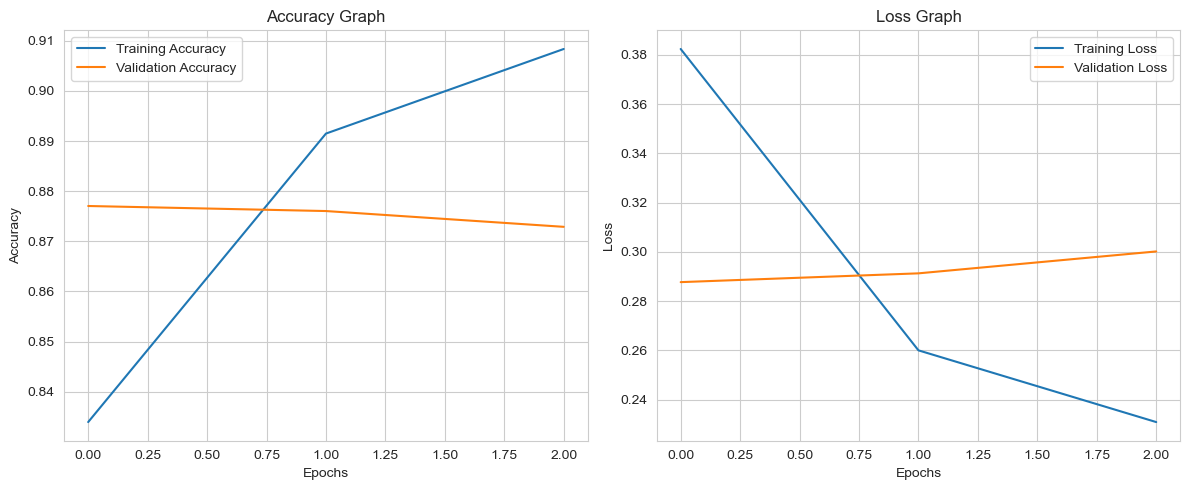

In [24]:
# Step 9: Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
# Step 10: Predict a Sample Review
sample_review = ["The movie had strong performances and a touching story."]
sample_clean = [clean_text(sample_review[0])]
sample_vector = vectorizer.transform(sample_clean).astype('float32').toarray()
sample_probability = model.predict(sample_vector, verbose=0)[0][0]
sample_label = 'positive' if sample_probability >= 0.5 else 'negative'

print('Review:', sample_review[0])
print('Predicted sentiment:', sample_label)
print('Positive probability:', round(float(sample_probability), 4))

Review: The movie had strong performances and a touching story.
Predicted sentiment: positive
Positive probability: 0.9824
